# Dog Bounding Box Detection
Uses a pre-trained YOLOv5 model to detect dogs and draw bounding boxes.

In [1]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2
import numpy as np
from audio_utils import load_data, spectrogram, plot_spectrogram
from scipy.optimize import linear_sum_assignment
import torch

In [ ]:
# Parameters
video_path = 'files/dogs1.mp4'
output_path = 'files/dogs1-output.mp4'

### Utils

In [3]:
# Stable tracker class with Kalman filter
def create_kalman_filter():
    kf = cv2.KalmanFilter(6, 4)

    kf.transitionMatrix = np.array([
        [1,0,0,0,1,0],
        [0,1,0,0,0,1],
        [0,0,1,0,0,0],
        [0,0,0,1,0,0],
        [0,0,0,0,1,0],
        [0,0,0,0,0,1],
    ], dtype=np.float32)

    kf.measurementMatrix = np.eye(4, 6, dtype=np.float32)
    kf.processNoiseCov = np.eye(6, dtype=np.float32) * 1e-2
    kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 1e-1
    kf.errorCovPost = np.eye(6, dtype=np.float32)

    return kf

def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    x, y, w, h = (x1 + x2) / 2, (y1 + y2) / 2, (x2 - x1), (y2 - y1)
    return np.array([[x], [y], [w], [h]], dtype=np.float32)

class StableTracker:
    def __init__(self, iou_threshold=0.4, max_age=10):
        self.next_stable_id = 0
        self.active = {} # {'box': (x1, y1, x2, y2), 'last_seen': frame_id, 'yolo_id': yolo_id}
        self.lost = {}
        self.yolo_to_stable = {}
        self.iou_threshold = iou_threshold
        self.max_age = max_age
        self.colors = {}

    def iou(self, a, b):
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b
        ix1, ix2, iy1, iy2 = max(ax1, bx1), min(ax2, bx2), max(ay1, by1), min(ay2, by2)
        iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)

        intersection = (iw * ih) if iw > 0 and ih > 0 else 0
        union = (ax2 - ax1) * (ay2 - ay1) + (bx2 - bx1) * (by2 - by1) - intersection

        return intersection / union if union > 0 else 0
    
    def update(self, detections, frame_id):
        # Predict lost trackers to current frame
        pred_boxes = {}

        for stable_id, data in self.lost.items():
            kf = data['kf']
            pred = kf.predict()
            x, y, w, h = pred[:4].flatten()
            pred_boxes[stable_id] = (x - w/2, y - h/2, x + w/2, y + h/2)

        unmatched_detections = []

        # Match YOLO detections to active stable IDs
        for box, yolo_id in detections:
            if yolo_id in self.yolo_to_stable:
                stable_id = self.yolo_to_stable[yolo_id]

                if stable_id in self.lost:
                    self.active[stable_id] = self.lost.pop(stable_id)
                if stable_id in self.active:
                    kf = self.active[stable_id]['kf']
                    kf.correct(xyxy_to_xywh(box))
                    self.active[stable_id]['box'] = box
                    self.active[stable_id]['last_seen'] = frame_id
                    self.yolo_to_stable[yolo_id] = stable_id
            else:
                unmatched_detections.append((box, yolo_id))

        # Match unmatched YOLO detections to lost stable IDs by IoU with predicted positions
        if unmatched_detections and self.lost:
            lost_ids = list(self.lost.keys())
            lost_boxes = [pred_boxes[stable_id] for stable_id in lost_ids]

            cost_matrix = np.zeros((len(unmatched_detections), len(lost_ids)), dtype=np.float32)

            for i, (box, _) in enumerate(unmatched_detections):
                for j, lost_box in enumerate(lost_boxes):
                    cost_matrix[i, j] = 1 - self.iou(box, lost_box)

            opt_det, opt_lost = linear_sum_assignment(cost_matrix) # Hungarian algorithm for optimal assignment

            still_unmatched = []

            for i, (box, yolo_id) in enumerate(unmatched_detections):
                matched = False

                for det, lost in zip(opt_det, opt_lost):
                    if det == i and cost_matrix[det, lost] < (1 - self.iou_threshold):
                        stable_id = lost_ids[lost]
                        self.active[stable_id] = self.lost.pop(stable_id)

                        kf = self.active[stable_id]['kf']
                        kf.correct(xyxy_to_xywh(box))
                        self.active[stable_id]['box'] = box
                        self.active[stable_id]['last_seen'] = frame_id
                        self.yolo_to_stable[yolo_id] = stable_id

                        matched = True
                        break        

                if not matched:
                    still_unmatched.append((box, yolo_id))
            
            unmatched_detections = still_unmatched

        # Before falling through to new stable ID, check active stable IDs by IoU with predicted positions
        if unmatched_detections and self.active:
            active_ids = list(self.active.keys())
            active_boxes = [self.active[stable_id]['box'] for stable_id in active_ids]

            cost_matrix = np.zeros((len(unmatched_detections), len(active_ids)), dtype=np.float32)

            for i, (box, _) in enumerate(unmatched_detections):
                for j, active_box in enumerate(active_boxes):
                    cost_matrix[i, j] = 1 - self.iou(box, active_box)

            opt_det, opt_active = linear_sum_assignment(cost_matrix) # Hungarian algorithm for optimal assignment

            still_unmatched = []

            for i, (box, yolo_id) in enumerate(unmatched_detections):
                matched = False

                for det, active in zip(opt_det, opt_active):
                    if det == i and cost_matrix[det, active] < (1 - self.iou_threshold):
                        stable_id = active_ids[active]
                        prev_yolo_id = self.active[stable_id]['yolo_id']

                        if prev_yolo_id in self.yolo_to_stable:
                            del self.yolo_to_stable[prev_yolo_id]

                        kf = self.active[stable_id]['kf']
                        kf.correct(xyxy_to_xywh(box))
                        self.active[stable_id]['box'] = box
                        self.active[stable_id]['last_seen'] = frame_id
                        self.active[stable_id]['yolo_id'] = yolo_id
                        self.yolo_to_stable[yolo_id] = stable_id

                        matched = True
                        break

                if not matched:
                    still_unmatched.append((box, yolo_id))

            unmatched_detections = still_unmatched

        # Add remaining unmatched YOLO detections as new stable IDs
        for box, yolo_id in unmatched_detections:
            stable_id = self.next_stable_id
            self.next_stable_id += 1
            
            kf = create_kalman_filter()
            x, y, w, h = xyxy_to_xywh(box).flatten()
            kf.statePre = np.array([[x],[y],[w],[h],[0],[0]], np.float32)
            kf.statePost = kf.statePre.copy()

            self.yolo_to_stable[yolo_id] = stable_id
            self.active[stable_id] = {'kf': kf, 'box': box, 'last_seen': frame_id, 'yolo_id': yolo_id}

        # Move stable IDs that have aged out to lost
        for stable_id, data in list(self.active.items()):
            if frame_id - data['last_seen'] > self.max_age:
                self.lost[stable_id] = self.active.pop(stable_id)

        # Return list of active stable IDs with their boxes
        final_active = []

        for stable_id, data in self.active.items():
            final_active.append((data['box'], stable_id))

        return final_active

/supernova/data/home/lillian/chihuahua/lib/python3.12/site-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/supernova/data/home/lillian/chihuahua/audio_utils.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  (s, framerate) = librosa.core.load(uploaded_file, sr=None, mono=False)
/supernova/data/home/lillian/chihuahua/lib/python3.12/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


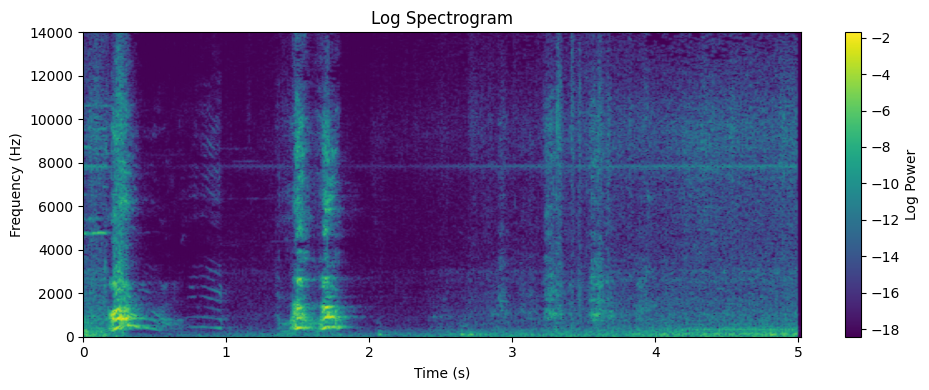

In [4]:
# Make dog bark spectrogram
vid = video_path
s, framerate = load_data(vid)

freqs, times, power, log_spec = spectrogram(vid, s, framerate)
plot_spectrogram(freqs, times, log_spec)

In [5]:
# Collect bark events
low_f = 300
high_f = 3000

band_mask = (freqs >= low_f) & (freqs <= high_f)
band_energy = log_spec[band_mask].mean(axis=0)

energy = (band_energy - np.mean(band_energy)) / (np.std(band_energy) + 1e-6)

threshold = 1
bark_frames = np.where(energy > threshold)[0]

bark_events = []
current = []

for idx in bark_frames:
    if not current or idx - current[-1] <= 2:
        current.append(idx)
    else:
        bark_events.append(current)
        current = [idx]

if current:
    bark_events.append(current)

bark_spec_ids = [int(np.mean(event)) for event in bark_events]

### YOLO

In [6]:
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO('yolov8n.pt')

# Load font
font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 40)

0: 640x512 1 dog, 40.7ms
Speed: 1.5ms preprocess, 40.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 512)


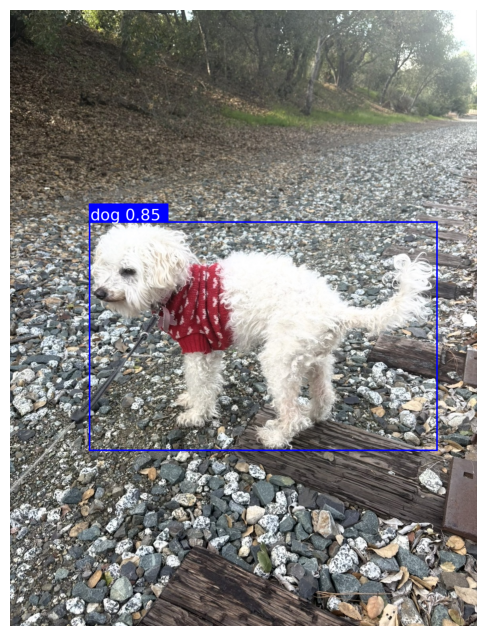

In [7]:
# Load dog image
img = Image.open('files/wynnie.jpg').convert('RGB')

# Run inference
results = model(img, device='cpu')


# Draw bounding boxes for dogs
draw = ImageDraw.Draw(img)
dog_count = 0

for result in results:
    for box in result.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        conf = float(box.conf[0])

        if label == 'dog' and conf > 0.5:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            draw.rectangle([x1, y1, x2, y2], outline='blue', width=4)
            draw.rectangle([x1, y1 - 45, x1 + 200, y1], fill='blue')
            draw.text((x1 + 4, y1 - 40), f'{label} {conf:.2f}', fill='white', font=font)

# Display result
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
# Helper to get spectrogram column for time t
def get_spec_col(t):
    return np.argmin(np.abs(times - t))

stable_tracker = StableTracker(iou_threshold=0.15, max_age=15)

print("Stable tracker initialized")

# Load dog video
cap = cv2.VideoCapture(video_path)

print("Video opened:", cap.isOpened())

fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Precompute spectrogram visualization
spec_full = np.flipud(log_spec)

spec_vis_full = cv2.normalize(spec_full, None, 0, 255, cv2.NORM_MINMAX)
spec_vis_full = spec_vis_full.astype(np.uint8)
spec_vis_full = cv2.applyColorMap(spec_vis_full, cv2.COLORMAP_INFERNO)
spec_vis_full = cv2.resize(spec_vis_full, (w, h))

# Video writer for output
out = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w * 2, h)
)

print("Writer opened:", out.isOpened())

frame_id = 0
interval = 3  # Run detection every 3 frames

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    t = frame_id / fps # Current time in seconds
    spec_id = get_spec_col(t)
    spec_vis = spec_vis_full.copy()
    x_pos = int(spec_id / log_spec.shape[1] * w)
    cv2.line(spec_vis, (x_pos, 0), (x_pos, h), (0, 255, 255), 3)

    # results = model(frame)

    results = model.track(frame, persist=True)

    r = results[0]

    print("ids:", r.boxes.id)

    if r.boxes is not None:
        boxes = r.boxes.xyxy.cpu().numpy()
        cls_ids = r.boxes.cls.cpu().numpy()
        confs = r.boxes.conf.cpu().numpy()
        yolo_ids = r.boxes.id.cpu().numpy() if r.boxes.id is not None else None

        detections = []
        for i in range(len(boxes)):
            if model.names[int(cls_ids[i])] == 'dog' and confs[i] > 0.25:
                if r.boxes.id is None:
                    continue
                detections.append((boxes[i], yolo_ids[i]))

        stable_results = stable_tracker.update(detections, frame_id)

        for box, stable_id in stable_results:
            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.rectangle(frame, (x1, y1 - 45), (x1 + 100, y1), (255, 0, 0), -1)
            cv2.putText(frame, f'dog #{stable_id}',
                        (x1 + 5, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 255, 255), 2)

    for bark_id in bark_spec_ids:
        if abs(bark_id - spec_id) < 10:  # only nearby ones
            x = int(bark_id / log_spec.shape[1] * w)

            cv2.rectangle(
                spec_vis,
                (x - 5, 0),
                (x + 5, h),
                (255, 0, 255),
                -1
            )

    frame = frame.astype('uint8')
    frame = np.ascontiguousarray(frame)

    frame = cv2.resize(frame, (w, h))
    spec_vis = cv2.resize(spec_vis, (w, h))
    frame = np.hstack([frame, spec_vis])

    out.write(frame)
    frame_id += 1

cap.release()
out.release()
cv2.destroyAllWindows()

print("Processing complete")

Stable tracker initialized
Video opened: True
Writer opened: True

0: 384x640 1 person, 2 dogs, 1 cow, 32.4ms
Speed: 1.9ms preprocess, 32.4ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4.])

0: 384x640 1 person, 2 dogs, 1 cow, 20.8ms
Speed: 0.9ms preprocess, 20.8ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4.])

0: 384x640 1 person, 3 dogs, 1 cow, 21.0ms
Speed: 1.0ms preprocess, 21.0ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4., 5.])

0: 384x640 1 person, 2 dogs, 1 cow, 20.3ms
Speed: 0.9ms preprocess, 20.3ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4.])

0: 384x640 2 persons, 3 dogs, 1 cow, 20.6ms
Speed: 1.0ms preprocess, 20.6ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


ids: tensor([1., 2., 3., 4., 8., 5.])

0: 384x640 1 person, 3 dogs, 1 cow, 21.1ms
Speed: 1.4ms preprocess, 21.1ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4., 5.])

0: 384x640 1 person, 2 dogs, 1 cow, 21.0ms
Speed: 1.2ms preprocess, 21.0ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4.])

0: 384x640 1 person, 2 dogs, 1 cow, 21.1ms
Speed: 0.8ms preprocess, 21.1ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4.])

0: 384x640 1 person, 2 dogs, 1 cow, 20.9ms
Speed: 1.0ms preprocess, 20.9ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4.])

0: 384x640 1 person, 2 dogs, 1 cow, 20.0ms
Speed: 0.9ms preprocess, 20.0ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
ids: tensor([1., 2., 3., 4.])

0: 384x640 2 persons, 2 dogs, 1 cow, 19.8ms
Speed: 0.8ms preprocess, 19.8ms inference, 0.4ms postproce

### RT-DETR

In [9]:
from ultralytics import RTDETR

# Load RT-DETR model
model = RTDETR("rtdetr-l.pt")

# Load font
font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 40)

In [10]:
# Helper to get spectrogram column for time t
def get_spec_col(t):
    return np.argmin(np.abs(times - t))

stable_tracker = StableTracker(iou_threshold=0.15, max_age=15)

print("Stable tracker initialized")

# Load dog video
cap = cv2.VideoCapture(video_path)

print("Video opened:", cap.isOpened())

fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Precompute spectrogram visualization
spec_full = np.flipud(log_spec)

spec_vis_full = cv2.normalize(spec_full, None, 0, 255, cv2.NORM_MINMAX)
spec_vis_full = spec_vis_full.astype(np.uint8)
spec_vis_full = cv2.applyColorMap(spec_vis_full, cv2.COLORMAP_INFERNO)
spec_vis_full = cv2.resize(spec_vis_full, (w, h))

# Video writer for output
out = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w * 2, h)
)

print("Writer opened:", out.isOpened())

frame_id = 0
interval = 3  # Run detection every 3 frames

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    t = frame_id / fps # Current time in seconds
    spec_id = get_spec_col(t)
    spec_vis = spec_vis_full.copy()
    x_pos = int(spec_id / log_spec.shape[1] * w)
    cv2.line(spec_vis, (x_pos, 0), (x_pos, h), (0, 255, 255), 3)

    # results = model(frame)

    results = model.track(frame, persist=True)

    r = results[0]

    if r.boxes is not None:
        boxes = r.boxes.xyxy.cpu().numpy()
        cls_ids = r.boxes.cls.cpu().numpy()
        confs = r.boxes.conf.cpu().numpy()
        yolo_ids = r.boxes.id.cpu().numpy() if r.boxes.id is not None else None

        detections = []
        for i in range(len(boxes)):
            if model.names[int(cls_ids[i])] == 'dog' and confs[i] > 0.5:
                if r.boxes.id is None:
                    continue
                detections.append((boxes[i], yolo_ids[i]))

        stable_results = stable_tracker.update(detections, frame_id)

        for box, stable_id in stable_results:
            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.rectangle(frame, (x1, y1 - 45), (x1 + 100, y1), (255, 0, 0), -1)
            cv2.putText(frame, f'dog #{stable_id}',
                        (x1 + 5, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 255, 255), 2)

    for bark_id in bark_spec_ids:
        if abs(bark_id - spec_id) < 10:  # only nearby ones
            x = int(bark_id / log_spec.shape[1] * w)

            cv2.rectangle(
                spec_vis,
                (x - 5, 0),
                (x + 5, h),
                (255, 0, 255),
                -1
            )

    frame = frame.astype('uint8')
    frame = np.ascontiguousarray(frame)

    frame = cv2.resize(frame, (w, h))
    spec_vis = cv2.resize(spec_vis, (w, h))
    frame = np.hstack([frame, spec_vis])

    out.write(frame)
    frame_id += 1

cap.release()
out.release()
cv2.destroyAllWindows()

print("Processing complete")

Stable tracker initialized
Video opened: True
Writer opened: True

0: 640x640 5 dogs, 1 sports ball, 1673.2ms
Speed: 2.2ms preprocess, 1673.2ms inference, 82.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 dogs, 1 sports ball, 180.7ms
Speed: 1.8ms preprocess, 180.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 dogs, 1 sports ball, 185.1ms
Speed: 1.5ms preprocess, 185.1ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 dogs, 1 sports ball, 197.6ms
Speed: 1.4ms preprocess, 197.6ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 dogs, 1 sports ball, 181.5ms
Speed: 1.5ms preprocess, 181.5ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 dogs, 1 sports ball, 206.8ms
Speed: 1.4ms preprocess, 206.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 dogs, 1 sports ball, 209.6ms
Speed: 1.4ms preprocess, 209.6ms inference